# **Drawing Shapes and Text in OpenCV**

---

## **Learning Objectives**

By the end of this notebook, you will be able to:

- Explain why drawing functions are essential in computer vision.
- Create a blank image using NumPy.
- Understand OpenCV's coordinate system.
- Represent colors using the BGR color space.
- Draw lines, rectangles, circles, and ellipses.
- Customize colors and thicknesses.

---

## **Prerequisites**

Before starting this notebook, you should be familiar with:

- Digital images and pixels
- NumPy arrays
- Reading and displaying images using OpenCV
- Image properties (`shape`, `size`, `dtype`, and `ndim`)
- The BGR color space
- Image channels

If you are new to any of these topics, it is recommended to review the previous notebooks before continuing.

---

# **Introduction**

Until now, we have focused on **reading**, **displaying**, and **manipulating** existing images. While these operations are fundamental, many computer vision applications also need to **draw** information onto images.

Drawing is far more than a way to create simple graphics. In computer vision, it is one of the primary methods of **visualizing the output of an algorithm**. Whether the task is detecting faces, recognizing objects, tracking movement, or measuring distances, the final results are usually presented by drawing shapes or text directly onto an image.

For example, drawing functions can be used to:

- Draw bounding boxes around detected objects.
- Highlight regions of interest.
- Display confidence scores.
- Mark feature points and keypoints.
- Visualize object trajectories.
- Label detected faces or landmarks.
- Annotate medical or satellite images.

Without these visual annotations, interpreting the output of many computer vision algorithms would be significantly more difficult.

Throughout this notebook, you will learn how to create images from scratch, draw geometric shapes, and add text using OpenCV. More importantly, you will gain an understanding of **how OpenCV creates these drawings by modifying the underlying pixel values**.

---

## **Why Drawing Matters in Computer Vision**

Imagine that you have trained an object detection model capable of locating cars in an image.

The algorithm successfully detects three vehicles and returns the following information:

```
Car 1:
x = 215
y = 132
width = 168
height = 94

Car 2:
x = 512
y = 240
width = 180
height = 102

Car 3:
x = 840
y = 156
width = 172
height = 98
```

Although these numerical values accurately describe the locations of the detected objects, they are not particularly intuitive for a human observer.

Now imagine displaying the same image with a rectangle drawn around each detected vehicle.

The information becomes immediately understandable.

This simple example illustrates why drawing functions are indispensable in computer vision. They transform numerical outputs into visual information that people can interpret at a glance.

Today, drawing functions are used in countless applications, including:

- Face detection
- Object detection
- OCR (Optical Character Recognition)
- Medical image analysis
- Autonomous driving
- Robotics
- Security and surveillance
- Sports analytics
- Augmented reality

In nearly every computer vision project, drawing functions are among the final steps before presenting the results to the user.

---

> 💡 **Did You Know?**
>
> Every rectangle, circle, line, and letter that OpenCV draws is created by changing the color values of individual pixels.
>
> OpenCV does not store shapes as separate objects. Once a shape is drawn, it becomes part of the image itself.

---

## **Theory**

Before learning the drawing functions, it is important to understand a key concept:

> **An image is simply a NumPy array.**

When we draw a shape, OpenCV does **not** place an object "on top" of the image. Instead, it directly modifies the values stored inside the image array.

For example, suppose we have a completely black image.

Every pixel contains the following value:

```python
(0, 0, 0)
```

which represents black in the BGR color space.

Now imagine drawing a red circle.

OpenCV determines which pixels belong to the circle and changes only those pixels to

```python
(0, 0, 255)
```

The remaining pixels stay unchanged.

The result is what appears to us as a red circle.

Understanding this idea is fundamental because **every drawing function in OpenCV follows exactly the same principle**—it identifies the pixels that belong to a shape and updates their color values.

---

## **Think Before You Run**

Imagine drawing a blue line across a white image.

Before looking at any code, consider the following questions:

- Does OpenCV create a separate "line object"?
- Or does it simply modify the pixels that lie along the path of the line?

Keep your answer in mind. By the end of this notebook, the process will become clear.

---

## **Understanding the Coordinate System**

Before drawing any shape, we must know **where** to draw it.

Every drawing function in OpenCV requires one or more coordinates that specify the position of the shape.

Unlike the Cartesian coordinate system used in mathematics, the origin of an image is located at the **top-left corner**.

```
                x

(0,0) ●────────────────────────►

      │
      │
      │
      │
      ▼

      y
```

The coordinate system follows two simple rules:

- The **x-coordinate** increases from left to right.
- The **y-coordinate** increases from top to bottom.

For example,

```
(150, 80)
```

means:

- Move **150 pixels** to the right.
- Move **80 pixels** downward.

The pixel at that location becomes the reference point for the drawing operation.

Almost every drawing function in OpenCV uses one or more coordinate pairs to determine the location of the shape.

For example:

- A line requires a starting point and an ending point.
- A rectangle requires two opposite corners.
- A circle requires a center point.
- Text requires the position of its first character.

Mastering the coordinate system is essential because every subsequent drawing operation depends on it.

---

## **Under the Hood**

Although we specify pixel locations using the familiar `(x, y)` format, OpenCV stores images as NumPy arrays.

NumPy accesses pixels using:

```python
image[row, column]
```

which is equivalent to

```python
image[y, x]
```

Whenever you provide coordinates such as

```python
(250, 120)
```

OpenCV automatically converts them internally to

```python
image[120, 250]
```

before modifying the corresponding pixels.

This conversion happens behind the scenes, allowing us to work with the more intuitive `(x, y)` coordinate system.

---

## **Common Mistakes**

- Confusing `(x, y)` with `(row, column)`.
- Assuming the origin is at the bottom-left corner.
- Forgetting that the y-axis increases downward.
- Using coordinates that lie outside the image boundaries.
- Assuming drawing functions create independent objects instead of modifying the image itself.

---

## **Best Practices**

- Sketch the approximate coordinates before writing the code.
- Use descriptive variable names such as `center`, `top_left`, and `bottom_right`.
- Keep image dimensions in mind when selecting coordinates.
- Remember that OpenCV expects coordinates in `(x, y)` order.

---

## **Experiment**

Without writing any code, answer the following questions:

1. Where is the pixel `(0, 0)` located?
2. If an image has dimensions `(600, 800)`, where is the bottom-right pixel?
3. If a circle is centered at `(400, 300)`, in which half of the image will it appear?
4. What happens if you specify a coordinate outside the image boundaries?

After making your predictions, verify them in the next sections when you begin drawing shapes.

---

## **Exercises**

1. Explain the difference between `(x, y)` coordinates and `(row, column)` indexing.
2. Why is the origin of an image located at the top-left corner instead of the bottom-left corner?
3. Describe how OpenCV represents a line internally.
4. Explain why drawing functions permanently modify an image unless a copy is created beforehand.
5. Give three examples of computer vision applications that use drawing functions.

---

## **Summary**

In this section, you learned why drawing functions are a fundamental part of computer vision. Rather than creating independent graphical objects, OpenCV draws by directly modifying the pixel values of an image.

You also learned how OpenCV's coordinate system differs from the traditional Cartesian plane and why understanding pixel coordinates is essential before drawing any shape.

In the next section, we will create our own blank canvas using NumPy and learn how OpenCV represents colors before drawing our first shapes.

---

## **Further Reading**

- OpenCV Documentation: **Drawing Functions**
- OpenCV Documentation: **Basic Operations on Images**
- NumPy Documentation: **Array Indexing

---

## **Creating a Blank Canvas**

An image in OpenCV is simply a NumPy array.

If every pixel is initialized to zero, the image becomes completely black.

Since OpenCV stores images as arrays, creating a new image is as easy as creating a NumPy array with the desired size.

The general syntax is:

```python
canvas = np.zeros((height, width, channels), dtype=np.uint8)
```

where

- **height** determines the number of rows
- **width** determines the number of columns
- **channels** is usually 3 for a color image (BGR)
- **dtype=np.uint8** stores each color value between 0 and 255

Every pixel initially contains

```
(B, G, R) = (0,0,0)
```

which represents pure black.

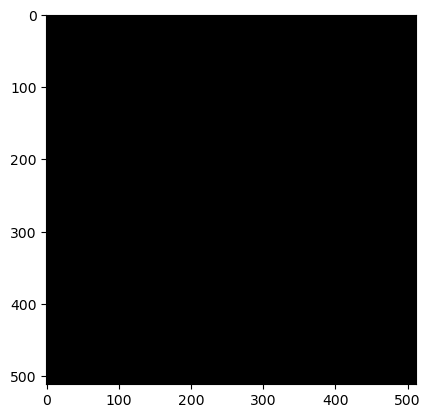

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

canvas = np.zeros((512, 512, 3), dtype=np.uint8)

plt.imshow(canvas[..., ::-1])
plt.show()

### **Understanding the Shape**

Suppose we create

```python
canvas = np.zeros((512, 512, 3), dtype=np.uint8)
```

The dimensions mean

```
Height = 512 pixels
Width  = 512 pixels
Channels = 3
```

The resulting array has the shape

```
(512, 512, 3)
```

Each pixel contains three numbers:

```
[Blue, Green, Red]
```

For example,

```
canvas[150,200]

Output:

[0 0 0]
```

This tells us the pixel at row 150 and column 200 is black.

In [2]:
print("Canvas's Shape: ", canvas.shape)
print("BGR Color Values For a Pixel: ", canvas[150, 200])

Canvas's Shape:  (512, 512, 3)
BGR Color Values For a Pixel:  [0 0 0]


### **Creating Different Background Colors**

A canvas doesn't have to be black.

Since an image is just a NumPy array, we can assign one color to every pixel.

For example,

```
canvas[:] = (255,255,255)
```

changes every pixel to white.

Likewise,

```
canvas[:] = (255,0,0)
```

creates a completely blue image because OpenCV uses the **BGR** color order.

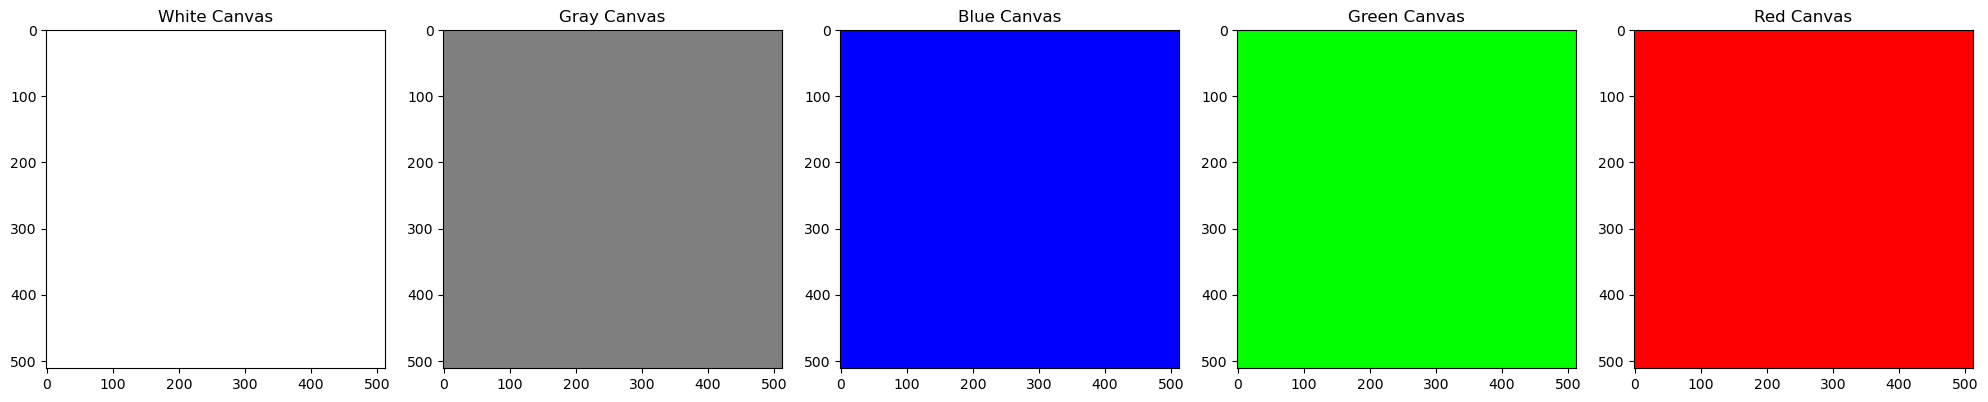

In [3]:
white_canvas = np.zeros((512, 512, 3), dtype=np.uint8)
white_canvas[:] = (255, 255, 255)

gray_canvas = np.zeros((512, 512, 3), dtype=np.uint8)
gray_canvas[:] = (127, 127, 127)

blue_canvas = np.zeros((512, 512, 3), dtype=np.uint8)
blue_canvas[:] = (255, 0, 0)

green_canvas = np.zeros((512, 512, 3), dtype=np.uint8)
green_canvas[:] = (0, 255, 0)

red_canvas = np.zeros((512, 512, 3), dtype=np.uint8)
red_canvas[:] = (0, 0, 255)

fig, axes = plt.subplots(figsize=(20, 5), nrows=1, ncols=5)
axes[0].imshow(white_canvas[..., ::-1]); axes[0].set_title("White Canvas")
axes[1].imshow(gray_canvas[..., ::-1]); axes[1].set_title("Gray Canvas")
axes[2].imshow(blue_canvas[..., ::-1]); axes[2].set_title("Blue Canvas")
axes[3].imshow(green_canvas[..., ::-1]); axes[3].set_title("Green Canvas")
axes[4].imshow(red_canvas[..., ::-1]); axes[4].set_title("Red Canvas")

plt.tight_layout()
plt.show()

### **Tip**

Remember that assigning

```python
canvas[:] = color
```

uses **NumPy slicing**.

The colon (`:`) means **select every row and every column**, so every pixel receives the same color.


In [4]:
if np.array_equal(canvas[:], canvas[:, :, :]):
    print("Arrays are identical.")

Arrays are identical.


## **Understanding Colors**

Every drawing function in OpenCV requires a color.

Unlike many other libraries that use **RGB (Red, Green, Blue)**, OpenCV uses

> **BGR (Blue, Green, Red)**

This is one of the most common mistakes beginners make.

For example,

```python
(255,0,0)
```

is **blue**, not red.

Similarly,

```python
(0,0,255)
```

is pure red.

Always remember the order:

```
Blue
Green
Red
```
---

### **Color Range**

Each color channel is represented by one byte.

This means every channel can store a value between (`0 - 255`).
Therefore,
```
(0,0,0)
```
is black,

```
(255,255,255)
```

is white.

Different combinations create different colors.

---

### **Some Common Colors**

| Color | BGR Value |
|--------|-----------|
| Black | (0,0,0) |
| White | (255,255,255) |
| Blue | (255,0,0) |
| Green | (0,255,0) |
| Red | (0,0,255) |
| Cyan | (255,255,0) |
| Yellow | (0,255,255) |
| Magenta | (255,0,255) |
| Gray | (128,128,128) |
| Orange | (0,165,255) |
| Purple | (128,0,128) |

---
## **Why Does OpenCV Use BGR?**

Historically, OpenCV inherited the BGR format from early image-processing libraries and camera hardware. Although RGB is more common today, OpenCV has kept BGR for backward compatibility.

Fortunately, converting between the two formats is simple:

```python
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
```

You'll frequently perform this conversion when displaying OpenCV images with **Matplotlib**, since Matplotlib expects RGB images.

---
## **Experiment**

Try changing the background color by assigning different values to the canvas:

```python
canvas[:] = (255,255,0)
```

What color do you expect?

Now try:

```python
canvas[:] = (40,180,220)
```

Can you predict the resulting color before running the code?

Experimenting with different BGR values is one of the best ways to become comfortable with OpenCV's color system.

---
## **Mini Challenge**

Create a canvas with a custom background color and display a small palette containing at least **six different colored squares**.

---

# **Draw Fundamental Geometric Shapes**

In this section, we'll learn how to draw the most fundamental geometric shapes in OpenCV.

These shapes are the building blocks for many computer vision applications.

You'll learn how to draw:

- Straight lines
- Rectangles
- Circles
- Ellipses

---

### **1. Drawing a Line**

The simplest drawing primitive is a **line**.

OpenCV provides the function:

```python
cv2.line()
```

General syntax:

```python
cv2.line(image,
         start_point,
         end_point,
         color,
         thickness,
         lineType=cv2.LINE_8)
```
---
#### **Parameters**

| Parameter | Description |
|-----------|-------------|
| image | Image to draw on |
| start_point | Starting coordinate `(x, y)` |
| end_point | Ending coordinate `(x, y)` |
| color | BGR color tuple |
| thickness | Width of the line in pixels |
| lineType | Drawing style (optional) |

Unlike NumPy indexing `(row, column)`, OpenCV coordinates are written as:

```
(x, y)
```

where

- **x** → horizontal position
- **y** → vertical position

The origin `(0,0)` is located at the **top-left corner** of the image.

---

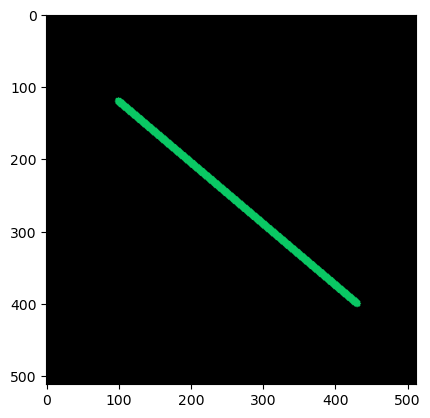

In [5]:
canvas = np.zeros((512, 512, 3), dtype=np.uint8)

cv2.line(canvas, pt1=(100, 120), pt2=(430, 400), color=(100, 200, 10), thickness=10)

plt.imshow(canvas[..., ::-1])
plt.show()

### **Understanding the Coordinates**

Suppose we draw

```python
cv2.line(canvas, (100, 120), (430, 400), ...)
```

The line begins at

```
x = 100
y = 120
```

and ends at

```
x = 430
y = 400
```

Notice that **x comes before y**.

This is different from NumPy indexing:

```python
canvas[y, x]
```

Remember:

| NumPy | OpenCV |
|--------|---------|
| `(row, column)` | `(x, y)` |
| `(y, x)` | `(x, y)` |

This difference is one of the most common sources of confusion for beginners.

---

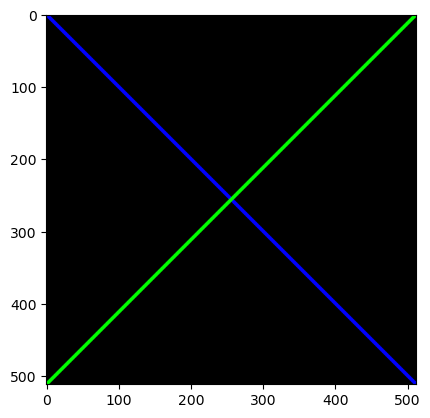

In [6]:
canvas = np.zeros((512, 512, 3), dtype=np.uint8)

cv2.line(canvas,(0,0),(512,512),(255,0,0),4)
cv2.line(canvas,(512,0),(0,512),(0,255,0),4)

plt.imshow(canvas[..., ::-1])
plt.show()

### **Experiment**

Try changing the following values:

- Start point
- End point
- Thickness
- Color

Questions:

- What happens if the thickness is `1`?
- What if the start and end points are the same?
- Can the line extend outside the image?

---

### **2. Drawing Rectangles**

Rectangles are probably the most frequently drawn shape in computer vision.

For example:

- Face detection
- Object detection
- License plate detection
- Image annotation

OpenCV uses

```python
cv2.rectangle()
```

Syntax

```python
cv2.rectangle(image,
              pt1,
              pt2,
              color,
              thickness)
```
---
#### **Parameters**

| Parameter | Description |
|-----------|-------------|
| pt1 | Top-left corner |
| pt2 | Bottom-right corner |
| color | BGR color |
| thickness | Border width |

Unlike many graphics libraries, OpenCV defines a rectangle using **two opposite corners**, not width and height.

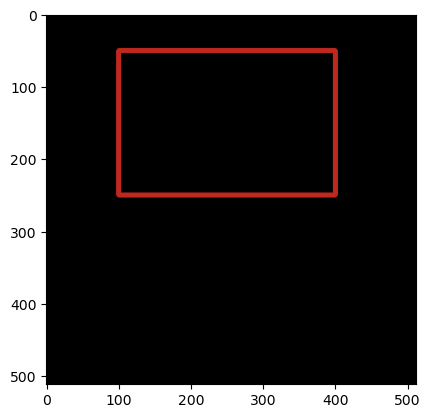

In [7]:
canvas = np.zeros((512, 512, 3), dtype=np.uint8)

cv2.rectangle(canvas, 
              pt1 = (100, 50),
              pt2 = (400, 250),
              color=(30, 40, 190),
             thickness=5)

plt.imshow(canvas[..., ::-1])
plt.show()

### Filled Rectangles

Instead of drawing only the border, OpenCV can fill the rectangle.

There are two equivalent ways:

```python
thickness = -1
```

or

```python
thickness = cv2.FILLED
```

Both tell OpenCV to color every pixel inside the rectangle.

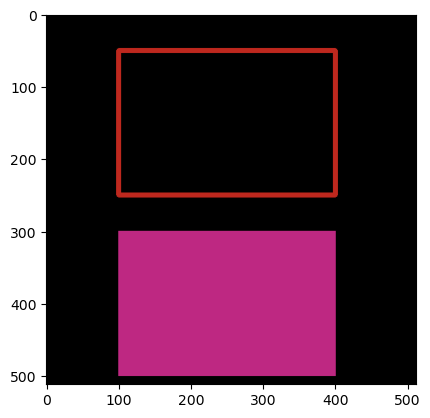

In [8]:
cv2.rectangle(canvas, 
              pt1 = (100, 300),
              pt2 = (400, 500),
              color=(130, 40, 190),
             thickness=-1)

plt.imshow(canvas[..., ::-1])
plt.show()

> **Tip**
>
> Object detection models such as YOLO, SSD, and Faster R-CNN often visualize predictions by drawing rectangles around detected objects using `cv2.rectangle()`.

### **3. Drawing Circles**

OpenCV draws circles using

```python
cv2.circle()
```

Syntax

```python
cv2.circle(image,
           center,
           radius,
           color,
           thickness)
```
---
#### **Parameters**

| Parameter | Description |
|-----------|-------------|
| center | Circle center `(x,y)` |
| radius | Radius in pixels |
| color | BGR color |
| thickness | Border width |

A circle is completely defined by its center and radius.

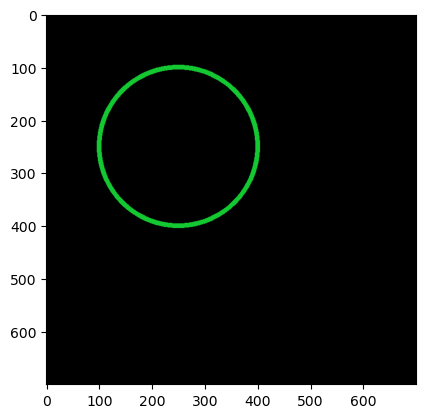

In [9]:
canvas = np.zeros((700, 700, 3), dtype=np.uint8)

cv2.circle(canvas, 
          center=(250, 250),
          radius=150,
          color=(50, 200, 20),
          thickness=7)

plt.imshow(canvas[..., ::-1])
plt.show()

### **Filled Circles**

Just like rectangles,

```python
thickness=-1
```

creates a filled circle.

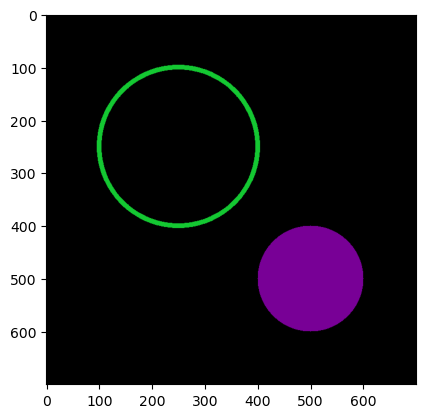

In [10]:
cv2.circle(canvas, 
          center=(500, 500),
          radius=100,
          color=(150, 0, 120),
          thickness=-1)

plt.imshow(canvas[..., ::-1])
plt.show()

### **Experiment**

Try changing:

- Radius
- Center position
- Thickness

Questions:

- What happens if the radius is larger than the image?
- What happens if the center is outside the canvas?

---

### **4. Drawing Ellipses**

An ellipse is a stretched circle.

OpenCV draws ellipses using

```python
cv2.ellipse()
```

General syntax

```python
cv2.ellipse(image,
            center,
            axes,
            angle,
            startAngle,
            endAngle,
            color,
            thickness)
```

Although this function has more parameters than the previous drawing functions, each one controls a specific aspect of the ellipse's appearance.

---
#### **Parameters**

| Parameter | Description |
|-----------|-------------|
| center | Center `(x,y)` |
| axes | Length of the semi-major and semi-minor axes `(axis_x, axis_y)` |
| angle | Rotation of the ellipse in degrees |
| startAngle | Starting angle of the arc |
| endAngle | Ending angle of the arc |
| color | BGR color |
| thickness | Border width |

Unlike a circle, an ellipse has two different radii:

```
Horizontal radius
Vertical radius
```

These are provided through the `axes` parameter.

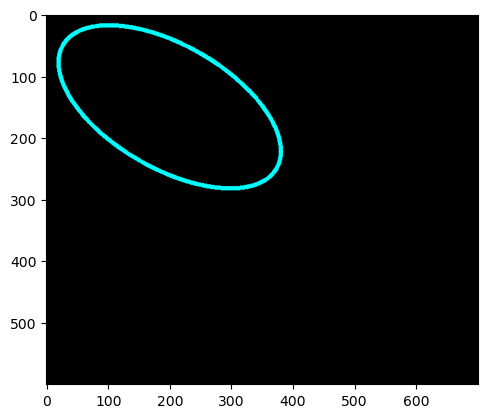

In [11]:
canvas = np.zeros((600,700,3), dtype=np.uint8)

cv2.ellipse(
    canvas,
    (200,150),
    (200,100),
    30,
    0,
    360,
    (255,255,0),
    5)

plt.imshow(canvas[..., ::-1])
plt.show()

### Drawing an Arc

An ellipse does not have to be complete.

By changing the starting and ending angles, you can draw only part of it.

For example,

```python
startAngle = 0
endAngle = 180
```

draws only half of the ellipse.

This is called an **elliptical arc**.

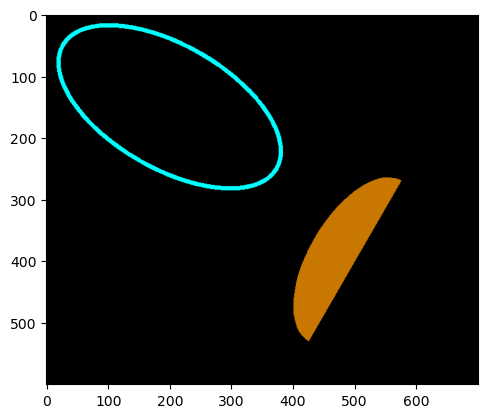

In [12]:
cv2.ellipse(
    canvas,
    (500, 400),
    (150, 75),
    120,
    0,
    180,
    (0, 120, 200),
    -1)

plt.imshow(canvas[..., ::-1])
plt.show()

## **Summary of Drawing Functions**

| Function | Main Parameters |
|----------|------------------|
| `cv2.line()` | Start point, end point |
| `cv2.rectangle()` | Two opposite corners |
| `cv2.circle()` | Center, radius |
| `cv2.ellipse()` | Center, axes, rotation, angles |

All drawing functions also require:

- An image (canvas)
- A BGR color
- A thickness

---
## **Practice Challenge**

Create a single image containing all four shapes:

- A blue diagonal line
- A green rectangle
- A filled red circle
- A rotated yellow ellipse

Try positioning the shapes so that none of them overlap.

Once you've finished, experiment with different colors, line thicknesses, and positions to better understand how each parameter affects the final drawing.